# TCSPC Fitting
The first cell imports necessary libraries and creates the functions needed to fit multiexponential functions to TCSPC data. The fit function convolves an instrument response function as part of the routine.

In [1]:
import numpy as np
from scipy.signal import fftconvolve
#from scipy.optimize import curve_fit
from scipy.ndimage import shift
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
import pandas as pd

####################################
# FUNCTION TO TRUNCATE DATA AND IRF
####################################
def trunc(data, irf, thresh, left, right, pnt):
    if pnt == 1: #start/stop are point numbers
        start = left
        stop = right
    else:
        start = (data['time'] - left).abs().idxmin()
        stop = (data['time'] - right).abs().idxmin()
    irf['clip'] = irf['counts']
    irf.loc[irf['counts'] < thresh, 'clip'] = 0 #get rid of noise in the IRF so it doesn't convolve
    irf['norm'] = irf['clip']/np.sum(irf['clip']) #normalize the IRF so it doesn't increase amplitude on convolution
    struct = {'time': data['time'].iloc[start:stop], 
                'irf': irf['norm'].iloc[start:stop], 
                'data': data['counts'].iloc[start:stop]
               }
    data4fit = pd.DataFrame(struct)
    #data4fit.head() 
    return data4fit

#######################################
#THE FITTING ALGORITHM
#######################################
#The fit parameters are
# pw[0] = shift
# pw [1] = baseline
# pw[2] = amplitude 1
# pw[3] = lifetime 1
# pw[2n] = amplitude n
# pw[2n+1] = lifetime n
def fit_multiexp(t, *args):
    pw = np.array(args[0], dtype=np.float64)
    shift = int(pw[0])
    baseline = pw[1]
    N = len(pw)-2
    pw_cut = pw[-N:]
    numtau = int(len(pw_cut))
    #print(f"The list has {numtau} lifetimes.")
    y = np.zeros_like(t)
    for index in range(0, numtau, 2):
        y += pw_cut[index] * np.exp(-t/pw_cut[index+1])
    roll_irf = np.roll(GLOBAL_IRF, shift)#shift(GLOBAL_IRF, shift)
    #####
    #t_shifted = np.arange(len(GLOBAL_IRF)) * DELTA_T + shift
    #roll_irf = np.interp(t_shifted, np.arange(len(GLOBAL_IRF)) * DELTA_T, GLOBAL_IRF)
    #####
    dup_model = np.concatenate((y, y))
    #out = fftconvolve(roll_irf, dup_model) + baseline
    out = np.convolve(roll_irf, dup_model, mode='full') + baseline
    L = len(t)
    return out[L:2*L]

def residual_function(params, x, y):
    """Computes the residuals (difference between observed and predicted y values)."""
    predicted_y = fit_multiexp(x, params)
    weights = np.sqrt(y)
    weights = weights.clip(lower=1)
    return (y - predicted_y)/weights

## Read an IRF
We'll demonstrate reading Becker-Hickl ascii format files. At the end of this notebook is a demonstration of reading Becker-Hickl .sdt files. This requires installation of `sdtfiles` package using the following command in a command prompt such as Anaconda Prompt.
```python
python -m pip install -U sdtfile
```

In [2]:
cols = ['time', 'counts']
irf = pd.read_csv('./irf/irf1.asc', sep='\\s+', dtype=np.float64, skiprows=10, skipfooter=2, names=cols, engine='python')
irf.shape

(4095, 2)

## Read a Data File
We continue to read a data file in Becker-Hickl ascii format.

In [3]:
data = pd.read_csv('./data/acr_0meoh100h2o.asc', sep='\\s+', dtype=np.float64, skiprows=10, skipfooter=2, names=cols, engine='python')
data.shape

(4095, 2)

### Plot to Check
Make a graph of the data and IRF to ensure they look correct. One could do other tests to ensure the TAC settings are identical, not shown here. In the next step, we will eliminate the background in the IRF. Take note of the number of maximum counts in the tail of the IRF. We will set a threshold for removing these.

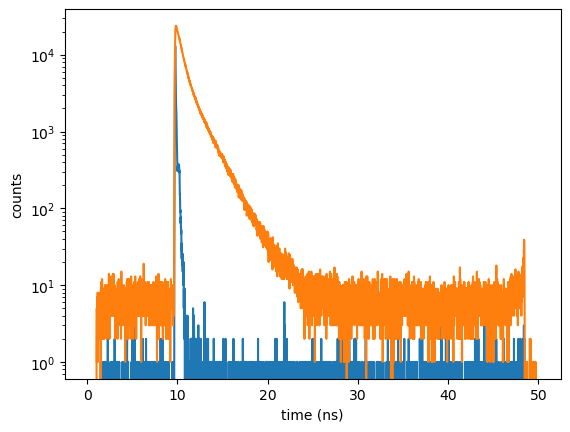

In [4]:
plt.semilogy(irf['time'], irf['counts'])
plt.semilogy(data['time'], data['counts'])
plt.xlabel('time (ns)')
plt.ylabel('counts')
plt.show()

## Truncate and Normalize the Arrays
In the functions at the beginning of this notebook, there is a `trunc(data, irf, threshold, start, stop, flag)` function. It takes input of data and IRF dataframes created when loading. The threshold parameter removes IRF background below this value. The IRF is also normalized in the process. In this example we set `thresh=10`. The `left` and `right` give the range of data and IRF to keep. These can be in indexes (`flag=1`) or times (`flag=0`). In the example we use times of `left=8` ns and `right=45` ns. The indexes for the same truncation are shown as a comment. We store the resulting truncated data and IRF in a dataframe named `data4fit`.

We set a global array to store the truncated and normalized IRF. We set a global variable for the time difference between two data points. These are necessary for the fitting function to access them.

In [5]:
#Create a dataframe for analysis
data4fit = trunc(data, irf, 10, 8, 45, 0) #using times
#data4fit = trunc(data, irf, 10, 667, 3698, 1) #using indexes
#Set the IRF as a global array
DELTA_T = data['time'].iloc[1] - data['time'].iloc[0]
GLOBAL_IRF = data4fit['irf']
data4fit.head()

,time,irf,data
655,7.995606,0.0,5.0
656,8.007813,0.0,8.0
657,8.020020,0.0,5.0
658,8.032227,0.0,4.0
659,8.044434,0.0,7.0


## Initial Fit
Fitting TCSPC data is challenging without decent initial guesses. Below, we make initial guesses of a two-exponential fit, create a test fit and plot the data and the test fit. It may take a few tries to the residuals to look evenly distributed around zero. The fit parameters are as follows.
```python
#The fit parameters are
# pw[0] = shift the IRF left (-) and right (+)
# pw [1] = baseline noise in photon counts
# pw[2] = amplitude of 1st lifetime
# pw[3] = lifetime 1 in ns
# pw[4] = amplitude of 2nd lifetime
# pw[5] = lifetime 2 in ns
...
# pw[2n] = amplitude n
# pw[2n+1] = lifetime n in ns
```

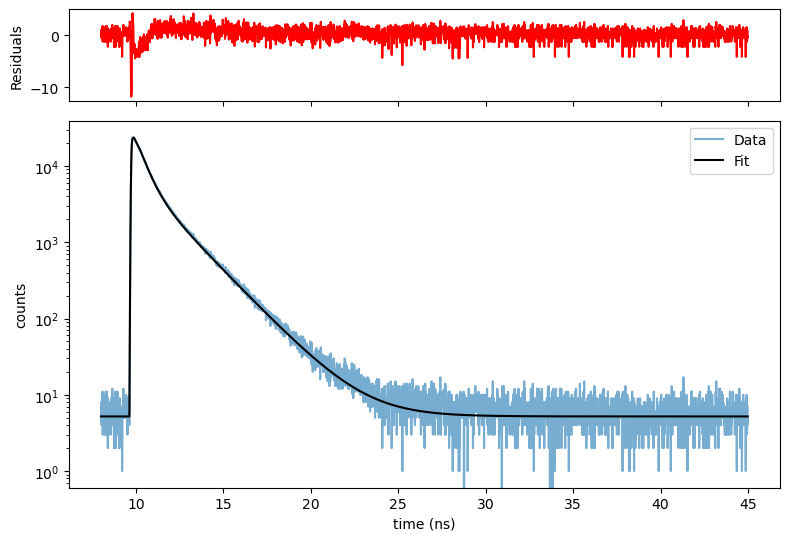

In [6]:
initial_guess = np.array([-2, 5.2, 1.2e11, 0.52, 5.8e5, 1.83])
testy = fit_multiexp(data4fit['time'], initial_guess)

# Create a figure and a single axes (subplot)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 4]})

ax1.plot(data4fit['time'], (data4fit['data']-testy)/np.sqrt(data4fit['data']), 'r-')
ax1.set_ylabel('Residuals')
#ax1.set_ylim([-5, 5])

ax2.semilogy(data4fit['time'], data4fit['data'], label='Data', alpha=0.6)
ax2.semilogy(data4fit['time'], fit_multiexp(data4fit['time'], initial_guess), 'k-', label='Fit')
ax2.set_ylabel('counts')
ax2.legend()

plt.xlabel('time (ns)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

## Perform the Fit
It's not necessary to copy the initial guess here, but it's nice to have everything in one cell. The fit is performed. The results are extracted and printed. The data and fit are plotted with the residuals above.

The fit below uses the lm method. According to scipy:
Levenberg-Marquardt algorithm as implemented in MINPACK. Doesn’t handle bounds and sparse Jacobians. Usually the most efficient method for small unconstrained problems.
There are some commented lines (2-5). If the default trf method is to be used, uncomment these and comment the 6th line beginning `result =`. According to scipy:
Trust Region Reflective algorithm, particularly suitable for large sparse problems with bounds. Generally robust method.

`ftol` termination condition is satisfied.
Function evaluations 4, initial cost 2.5608e+03, final cost 2.0886e+03, first-order optimality 1.35e-03.
Optimized Fit Parmeters: [-2.00000000e+00  5.03991276e+00  1.15712096e+11  5.19744628e-01
  5.99066201e+05  1.83182273e+00]
Reduced Chi Squared =  1.3808972221843343


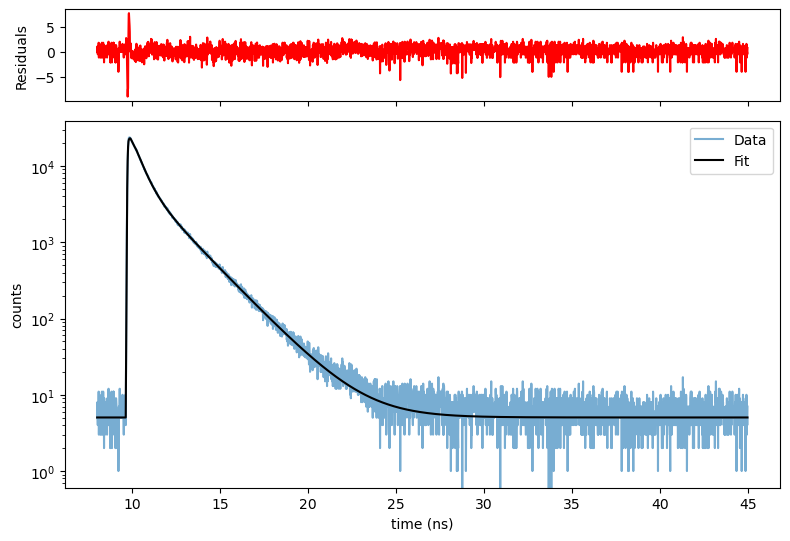

In [7]:
initial_guess = np.array([-2, 5.2, 1.2e11, 0.52, 5.8e5, 1.83])
#lower_bounds = [-10, 1, 10, 0.01, 10, 0.01]
#upper_bounds = [10, 20, 1e7, 10, 1e7, 10]
#bounds = (lower_bounds, upper_bounds)
#result = least_squares(residual_function, initial_guess, args=(data4fit['time'], data4fit['data']), bounds=bounds, method='trf', verbose=1)
result = least_squares(residual_function, initial_guess, args=(data4fit['time'], data4fit['data']), method='lm', verbose=1)
optimal_params = np.array(result.x)
print("Optimized Fit Parmeters:", optimal_params)
print("Reduced Chi Squared = ", np.sum(result.fun**2)/(len(data4fit['data'])-len(initial_guess)))

# Create a figure and a single axes (subplot)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 4]})

ax1.plot(data4fit['time'], result.fun, 'r-')
ax1.set_ylabel('Residuals')
#ax1.set_ylim([-5, 5])

ax2.semilogy(data4fit['time'], data4fit['data'], label='Data', alpha=0.6)
ax2.semilogy(data4fit['time'], fit_multiexp(data4fit['time'], optimal_params), 'k-', label='Fit')
ax2.set_ylabel('counts')
ax2.legend()

plt.xlabel('time (ns)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

# Loading Becker-Hickl sdt Files

In [8]:
from sdtfile import *

In [9]:
irfsdt = SdtFile('./irf/irf2.sdt')

## Extracting only the data
The loaded data has a complicated format. Assuming there is only one block of data, the times and photon counts can be extracted using the following method. The result is a pandas dataframe `irf` that is identical to the one created above when loading the ascii format.

In [10]:
struct={'time': irfsdt.times[0],
        'counts': irfsdt.data[0][0]
}
irf = pd.DataFrame(struct)
irf.head()

,time,counts
0,0.000000e+00,0
1,1.220703e-11,0
2,2.441406e-11,0
3,3.662109e-11,0
4,4.882813e-11,0


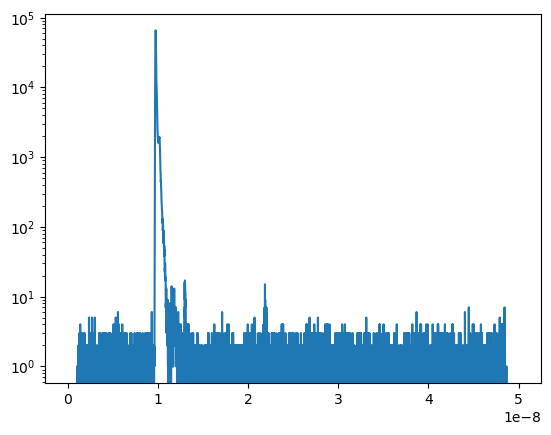

In [11]:
#Plot the dataframe
plt.semilogy(irf['time'], irf['counts'])
plt.show()

# Loading PicoQuant Files
This is a demonstration of reading PicoQuant .ptu files. This requires installation of `ptufiles` package using the following command in a command prompt such as Anaconda Prompt.
```python
python -m pip install -U "ptufile[all]"
```

I do not have instrument response functions to demonstrate all of the steps. However, below, I demonstrate how to create a dataframe for the TCSPC lifetime. The same process would be used for an IRF dataframe. Then, the truncation function can be used to assemble a fitting dataframe and proceed with the rest of the fitting process.

In [12]:
#import the ptu library
from ptufile import * 

In [13]:
#read a file and make sure it is T3 (TCSPC lifetime) filetype
ptu = PtuFile('./data/atto647AuNP_1.ptu')
ptu.record_type

<PtuRecordType.PicoHarpT3: 66307>

We can look at the shape. The last number tells us the number of bins in the TAC.

In [14]:
#check the shape
ptu.shape

(1, 256, 256, 1, 1564)

Then, we get the resolution to know the timestep between each TAC bin.

In [15]:
resolution = ptu.tags['MeasDesc_Resolution']
print(f"Resolution: {resolution} seconds")

Resolution: 1.5999999936067155e-11 seconds


The 1564 bins each separated by 16 picoseconds implies the TAC window was 1564 x 0.016 = 25 nanoseconds.

Decode the file information so that we can pull out the `dtime` array, which is the TAC bin number for each detected photon.

In [16]:
decoded = ptu.decode_records()
decoded.dtype

dtype([('time', '<u8'), ('dtime', '<i2'), ('channel', 'i1'), ('marker', 'u1')])

Finally, we can plot a histogram of the TAC bins and scale the histogram using the number of bins and the resolution. We'll assemble this into a pandas dataframe and plot it.

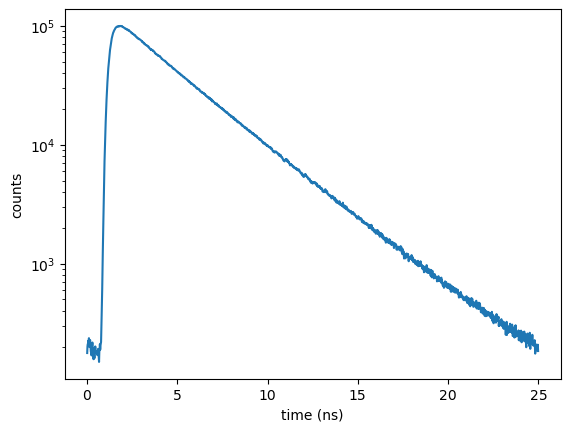

In [17]:
hist, bin_edges = np.histogram(decoded['dtime'], bins=1564, range=None, density=False, weights=None)
time_ptu = np.linspace(0, 25, 1564) #create an array from 0 to 25 ns with 1564 bins
#set up the dataframe columns
struct = {'time': time_ptu, 'counts': hist}
#make the dataframe
data_ptu = pd.DataFrame(struct)

#make a plot using the dataframe
plt.semilogy(data_ptu['time'].iloc[1:1563], data_ptu['counts'].iloc[1:1563])#cutting off weird digitization at the beginning
plt.xlabel('time (ns)')
plt.ylabel('counts')
plt.show()